# Extract simulated internal states 

These are not easily experimentally verified!

2025/06/13

Andrew Weng

In [11]:
import os, sys

# Move the path up a level to be able to index into source files
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('../')
    sys.path.insert(0, 'src/')

from src import cellsim as cellsim

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from src import plotter as plotter
from src import ioutils as ioutils
from src import simutils as simutils
from scipy.interpolate import interp1d
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

%load_ext autoreload
%matplotlib widget
plotter.initialize(plt)

target_dir = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
# Calculate the density of the pure SEI components
rho_vc = 86.05 / 5.810e-5 * 1e-6
rho_ec = 88.06 / 9.585e-5 * 1e-6

rho_vc = 1.3
rho_ec = 1.6
# Set the resistance scaling factor
gamma_kappa = 3367 * 2

In [13]:
# With optimal d_ec and d_vc values
d_ec_opt1 = 3.2e-20  # Optimal d_ec for base
d_ec_opt2 = 3.2e-20  # Optimal d_ec for fast
d_ec_opt3 = 5.1e-20  # Optimal d_ec for fast+
d_vc_opt1 = 4.2e-16  # Optimal d_vc for base
d_vc_opt2 = 3.2e-17  # Optimal d_vc for fast
d_vc_opt3 = 3.2e-17  # Optimal d_vc for fast+
d_ec_b = 4.2e-20  # Baseline d_ec from Weng2023
d_vc_b = 6.6e-18  # Baseline d_vc from Weng2023

In [ ]:
# With optimal d_ec and d_vc values
# df_sim1 = simutils.run_sim('base', 3.2e-20, 4.2e-16, gamma_kappa, dt=5, to_follow_current=False, to_simulate_form_aging=True, to_simulate_cycling=False)
# df_sim2 = simutils.run_sim('fast', 3.2e-20, 3.2e-17, gamma_kappa, dt=5, to_follow_current=False, to_simulate_form_aging=True, to_simulate_cycling=False)
# df_sim3 = simutils.run_sim('fast+', 5.1e-20, 3.2e-17, gamma_kappa, dt=1, to_follow_current=False, to_simulate_form_aging=True, to_simulate_cycling=False)

df_sim1 = simutils.run_sim('base', 4.2e-20, 6.6e-18, gamma_kappa, dt=1, to_follow_current=False, to_simulate_form_aging=True, to_simulate_cycling=True)
df_sim2 = simutils.run_sim('fast', 4.2e-20, 6.6e-18, gamma_kappa, dt=1, to_follow_current=False, to_simulate_form_aging=True, to_simulate_cycling=True)
df_sim3 = simutils.run_sim('fast+', 4.2e-20, 6.6e-18, gamma_kappa, dt=1, to_follow_current=False, to_simulate_form_aging=True, to_simulate_cycling=True)

df_sim1o = simutils.run_sim('base', d_ec_opt1, d_vc_opt1, dt=1, to_follow_current=False, to_simulate_form_aging=True, to_simulate_cycling=True)
df_sim2o = simutils.run_sim('fast', d_ec_opt2, d_vc_opt2, dt=1, to_follow_current=False, to_simulate_form_aging=True, to_simulate_cycling=True)
df_sim3o = simutils.run_sim('fast+', d_ec_opt3, d_vc_opt3, dt=1, to_follow_current=False, to_simulate_form_aging=True, to_simulate_cycling=True)

# With the baseline d_ec and d_vc values
# df_sim1 = simutils.run_sim('base', 3.2e-20, 4.2e-16, gamma_kappa, dt=5, to_follow_current=False, to_simulate_form_aging=True, to_simulate_cycling=True)
# df_sim2 = simutils.run_sim('fast', 3.2e-20, 4.2e-16, gamma_kappa, dt=5, to_follow_current=False, to_simulate_form_aging=True, to_simulate_cycling=True)
# df_sim3 = simutils.run_sim('fast+', 3.2e-20, 4.2e-16, gamma_kappa, dt=1, to_follow_current=False, to_simulate_form_aging=True, to_simulate_cycling=True)


KeyboardInterrupt: 

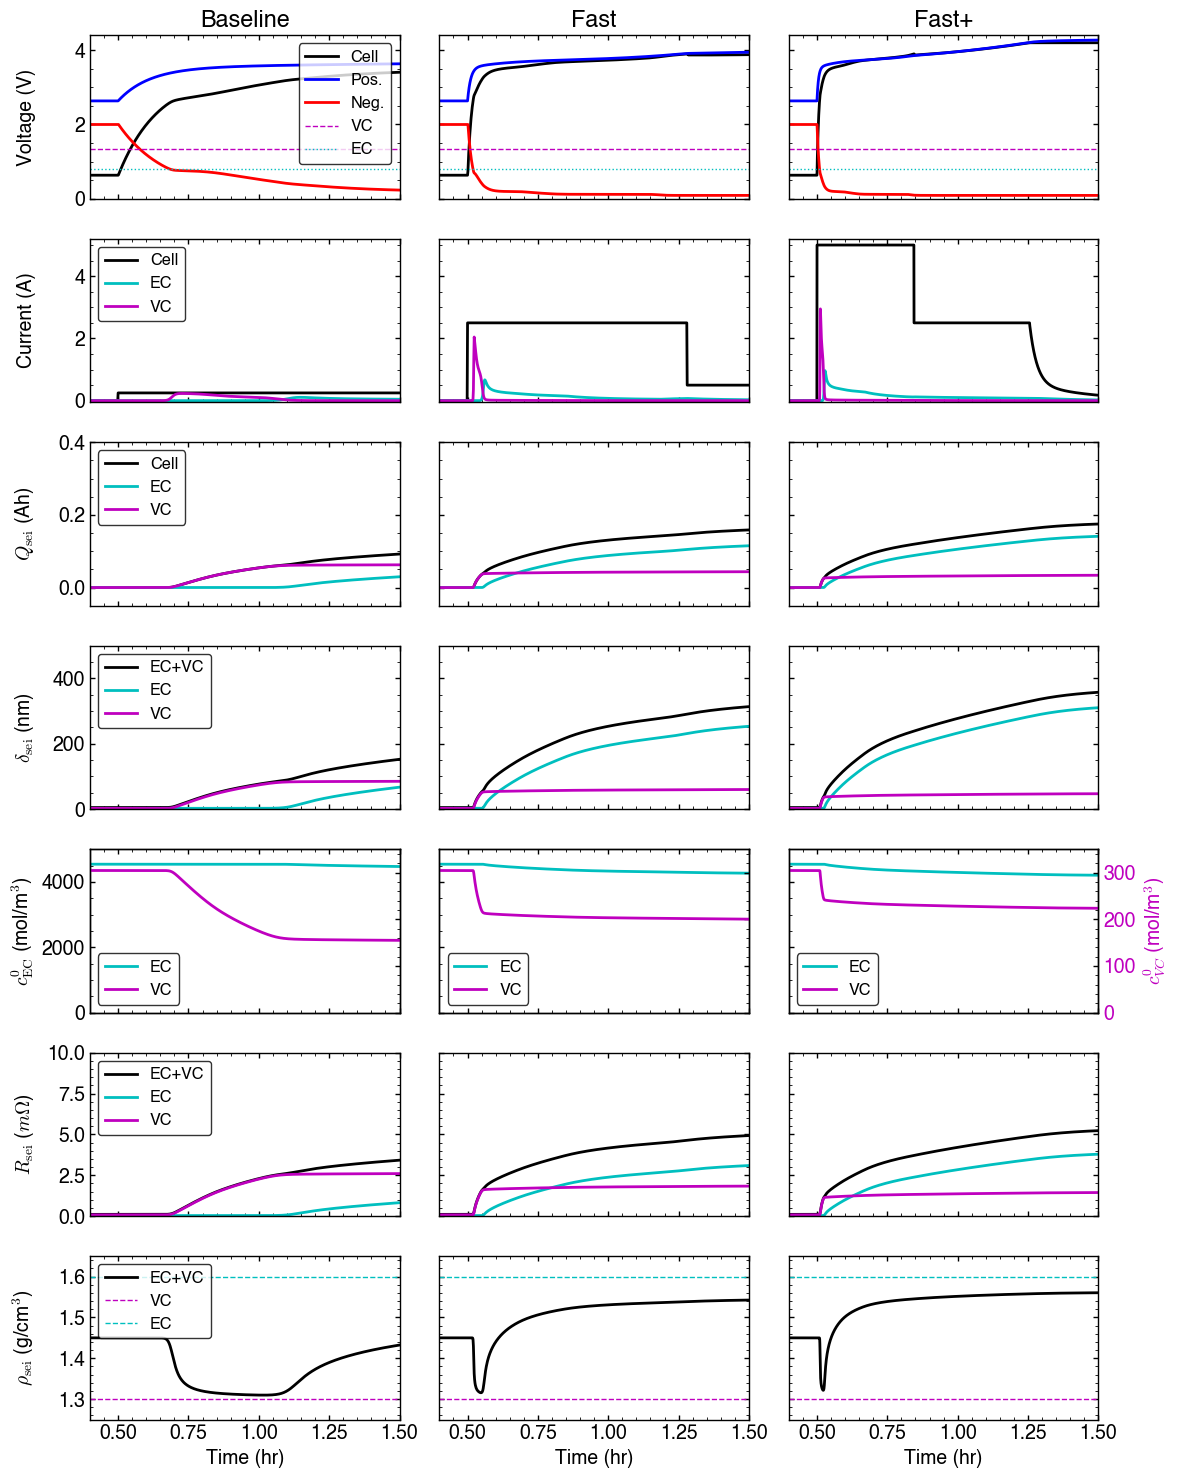

In [ ]:
%matplotlib inline

fig, axes = plt.subplots(7, 3, figsize=(12, 15), sharex='col')

# DataFrames and titles for columns
dfs = [df_sim1, df_sim2, df_sim3]
titles = ['Baseline', 'Fast', 'Fast+']

# Row labels and y-data
row_info = [
    ([('vt', 'Cell', 'k'),
      ('ocv_p', 'Pos.', 'b'),
      ('ocv_n', 'Neg.', 'r')], 'Voltage (V)', (0, 4.4)),
    ([('i_app', 'Cell', 'k'),
      ('i_sei1', 'EC', 'c'),
      ('i_sei2', 'VC', 'm')], 'Current (A)', (-0.05, 5.2)),
    ([('q_sei', 'Cell', 'k'),
      ('q_sei1', 'EC', 'c'),
      ('q_sei2', 'VC', 'm')], r'$Q_{\mathrm{sei}}$ (Ah)', (-0.05, 0.4)),
    ([('delta_sei', 'EC+VC', 'k'),
      ('delta_sei1', 'EC', 'c'),
      ('delta_sei2', 'VC', 'm')], r'$\delta_{\mathrm{sei}}$ (nm)', (0, 0.5e-6)),
    ([('c_sei1', 'EC', 'c')], r'$c^0_{\mathrm{EC}}$ (mol/m$^3$)', (0, 5000)),
    ([('R_sei', 'EC+VC', 'k'),
      ('R_sei1', 'EC', 'c'),
      ('R_sei2', 'VC', 'm')], r'$R_{\mathrm{sei}}$ ($m\Omega$)', (0, 0.01)),
    ([('rho_sei', 'EC+VC', 'k')], r'$\rho_{\mathrm{sei}}$ (g/cm$^3$)', (1.25, 1.65)) # q_sei again as requested
]

for col, (df, title) in enumerate(zip(dfs, titles)):
    for row, (yinfo, ylabel, ylim) in enumerate(row_info):

        ax = axes[row, col]
        ax.set_ylim(ylim)

        for _, (key, label, color) in enumerate(yinfo):
            ax.plot(df['t']/3600, df[key], label=label, color=color)

        if col == 0:
            ax.set_ylabel(ylabel)


        if row == 0: # VOLTAGE
            ax.axhline(1.35, color='m', linestyle='--', linewidth=1, label='VC')
            ax.axhline(0.8, color='c', linestyle=':', linewidth=1, label='EC')
            ax.set_title(title)

        if row == 1: # CURRENT
            pass
            # ax.set_yscale('log')

        if row == 3: # SEI THICKNESS
            for line in ax.get_lines():
                line.set_ydata(line.get_ydata() * 1e9)
                ax.set_ylim(ylim[0] * 1e9, ylim[1] * 1e9)

        if row == 4: # SEI CONCENTRATION
            # Plot VC (c_sei2) on a secondary y-axis
            ax2 = ax.twinx()
            ax2.plot(df['t']/3600, df['c_sei2'], color='m', label='VC', linestyle='-')
            
            ax2.set_ylabel(r'$c^0_{VC}$ (mol/m$^3$)', color='m')
            ax2.tick_params(axis='y', labelcolor='m')
            ax2.set_ylim(0, 350)
            ax2.grid(False)

            if col != axes.shape[1] - 1:
                ax2.set_yticklabels([])
                ax2.set_ylabel('')
            
            # Combine legends from both axes
            lines, labels = ax.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax2.legend(lines + lines2, labels + labels2, loc='lower left',
                    fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black')

        if row == 5: # SEI RESISTANCE
            for line in ax.get_lines():
                line.set_ydata(line.get_ydata() * 1e3)
                ax.set_ylim(ylim[0] * 1e3, ylim[1] * 1e3)
    
        if row == 6: # DENSITY
            ax.axhline(rho_vc, color='m', linestyle='--', linewidth=1, label='VC')
            ax.axhline(rho_ec, color='c', linestyle='--', linewidth=1, label='EC')
            ax.set_xlabel('Time (hr)')

        # Only add legend for the first column
        if col == 0 and row != 4:
            loc = 'upper right' if row == 0 else 'upper left'
            ax.legend(loc=loc, fontsize='small', frameon=True, 
                      facecolor=(1,1,1,0), edgecolor='black')
    

# Turn off grids in all subplots
for ax_row in axes:
    for ax in ax_row:
        ax.set_xlim(0.4, 1.5)
        ax.grid(False)

# Only show y-axis markers on the left column
for col in range(1, axes.shape[1]):
    for row in range(axes.shape[0]):
        axes[row, col].set_yticklabels([])
        axes[row, col].set_ylabel('')

# Lock y-limits across each row
for row in range(axes.shape[0]):
    ymins, ymaxs = [], []
    for col in range(axes.shape[1]):
        ymins.append(axes[row, col].get_ylim()[0])
        ymaxs.append(axes[row, col].get_ylim()[1])
    ymin, ymax = min(ymins), max(ymaxs)
    for col in range(axes.shape[1]):
        axes[row, col].set_ylim(ymin, ymax)

fig.align_ylabels(axes[:, 0])

# plt.tight_layout()
fig.subplots_adjust(hspace=0, wspace=0, 
                    right=1, left=0, top=1, bottom=0)

# plt.show()
fig.savefig("sei_summary_1p5_global_dsei.svg", format="svg")

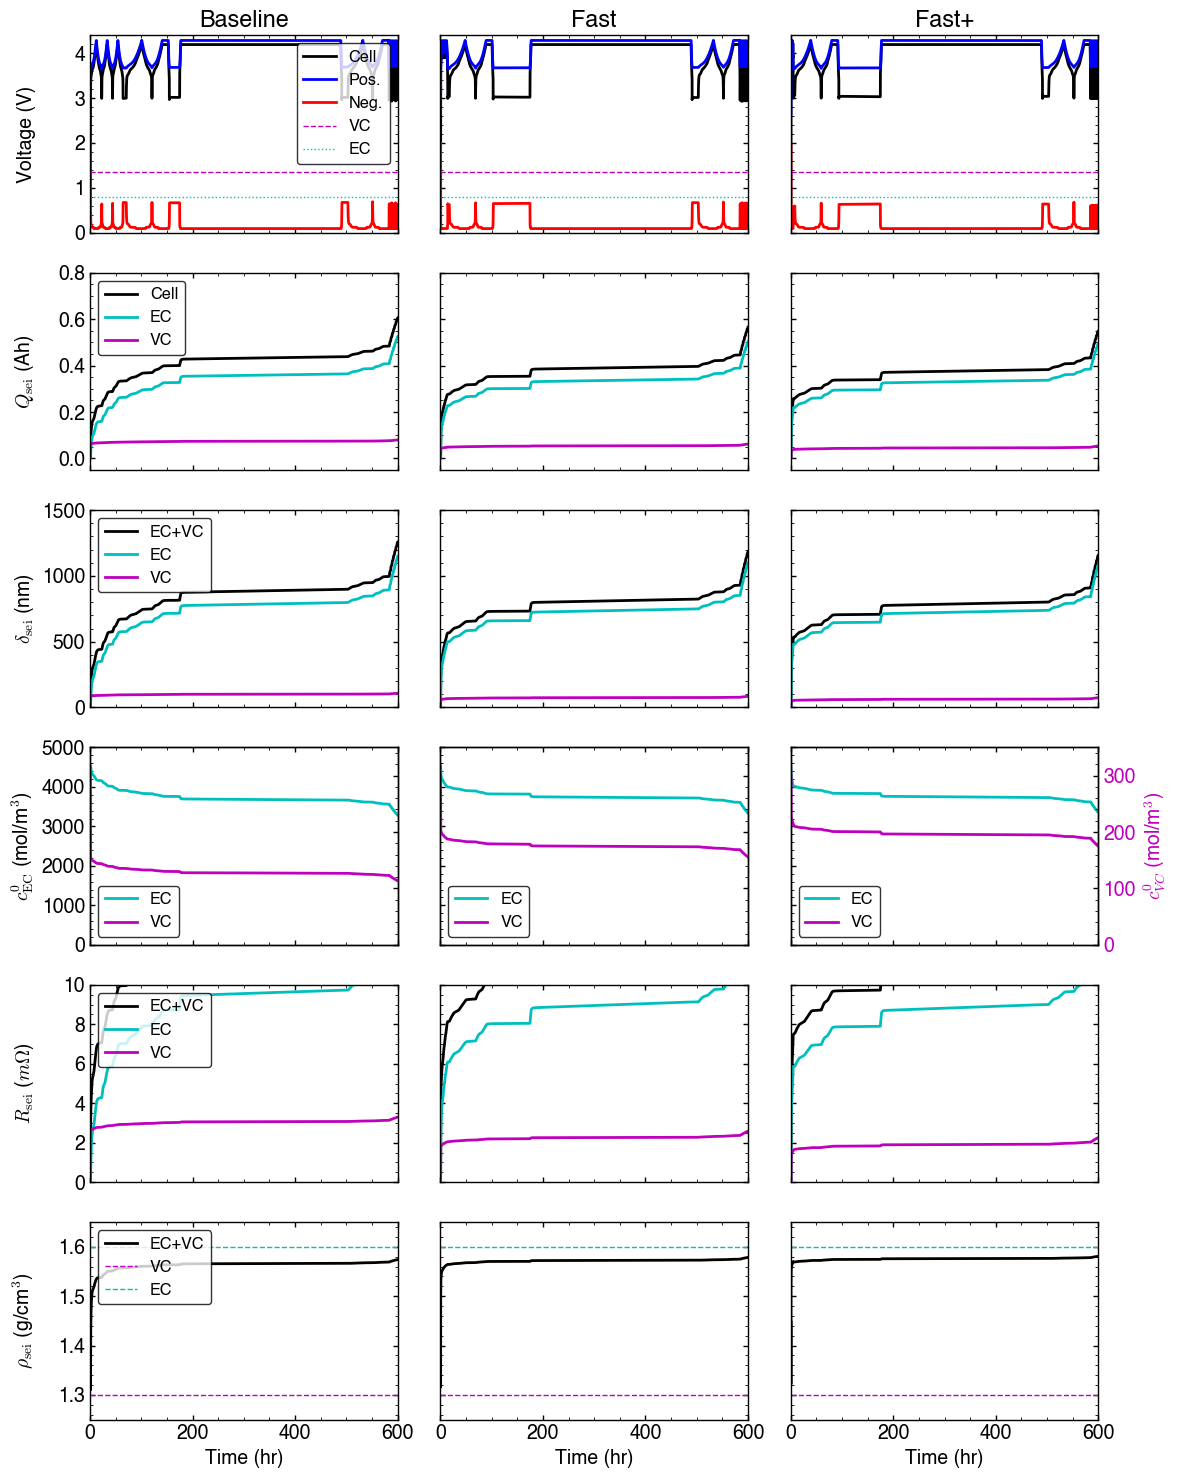

In [ ]:
%matplotlib inline

fig, axes = plt.subplots(6, 3, figsize=(12, 15), sharex='col')

# DataFrames and titles for columns
dfs = [df_sim1, df_sim2, df_sim3]
titles = ['Baseline', 'Fast', 'Fast+']

# Row labels and y-data
row_info = [
    ([('vt', 'Cell', 'k'),
      ('ocv_p', 'Pos.', 'b'),
      ('ocv_n', 'Neg.', 'r')], 'Voltage (V)', (0, 4.4)),
    ([('q_sei', 'Cell', 'k'),
      ('q_sei1', 'EC', 'c'),
      ('q_sei2', 'VC', 'm')], r'$Q_{\mathrm{sei}}$ (Ah)', (-0.05, 0.8)),
    ([('delta_sei', 'EC+VC', 'k'),
      ('delta_sei1', 'EC', 'c'),
      ('delta_sei2', 'VC', 'm')], r'$\delta_{\mathrm{sei}}$ (nm)', (0, 1.5e-6)),
    ([('c_sei1', 'EC', 'c')], r'$c^0_{\mathrm{EC}}$ (mol/m$^3$)', (0, 5000)),
    ([('R_sei', 'EC+VC', 'k'),
      ('R_sei1', 'EC', 'c'),
      ('R_sei2', 'VC', 'm')], r'$R_{\mathrm{sei}}$ ($m\Omega$)', (0, 10)),
    ([('rho_sei', 'EC+VC', 'k')], r'$\rho_{\mathrm{sei}}$ (g/cm$^3$)', (1.25, 1.65)) # q_sei again as requested
]

for col, (df, title) in enumerate(zip(dfs, titles)):
    for row, (yinfo, ylabel, ylim) in enumerate(row_info):

        ax = axes[row, col]
        ax.set_ylim(ylim)

        for _, (key, label, color) in enumerate(yinfo):
            ax.plot(df['t']/3600, df[key], label=label, color=color)

        if col == 0:
            ax.set_ylabel(ylabel)


        if row == 0: # VOLTAGE
            ax.axhline(1.35, color='m', linestyle='--', linewidth=1, label='VC')
            ax.axhline(0.8, color='c', linestyle=':', linewidth=1, label='EC')
            ax.set_title(title)

        if row == 2: # SEI THICKNESS
            for line in ax.get_lines():
                line.set_ydata(line.get_ydata() * 1e9)
                ax.set_ylim(ylim[0] * 1e9, ylim[1] * 1e9)

        if row == 3: # SEI CONCENTRATION
            # Plot VC (c_sei2) on a secondary y-axis
            ax2 = ax.twinx()
            ax2.plot(df['t']/3600, df['c_sei2'], color='m', label='VC', linestyle='-')
            
            ax2.set_ylabel(r'$c^0_{VC}$ (mol/m$^3$)', color='m')
            ax2.tick_params(axis='y', labelcolor='m')
            ax2.set_ylim(0, 350)
            ax2.grid(False)

            if col != axes.shape[1] - 1:
                ax2.set_yticklabels([])
                ax2.set_ylabel('')
            
            # Combine legends from both axes
            lines, labels = ax.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax2.legend(lines + lines2, labels + labels2, loc='lower left',
                    fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black')

        if row == 4: # SEI RESISTANCE
            for line in ax.get_lines():
                line.set_ydata(line.get_ydata() * 1e3)
                # ax.set_ylim(ylim[0] * 1e3, ylim[1] * 1e3 * 1e-4)
    
        if row == 5: # DENSITY
            ax.axhline(rho_vc, color='m', linestyle='--', linewidth=1, label='VC')
            ax.axhline(rho_ec, color='c', linestyle='--', linewidth=1, label='EC')
            ax.set_xlabel('Time (hr)')

        # Only add legend for the first column
        if col == 0 and row != 3:
            loc = 'upper right' if row == 0 else 'upper left'
            ax.legend(loc=loc, fontsize='small', frameon=True, 
                      facecolor=(1,1,1,0), edgecolor='black')
    

# Turn off grids in all subplots
for ax_row in axes:
    for ax in ax_row:
        ax.set_xlim(0, 600)
        ax.grid(False)

# Only show y-axis markers on the left column
for col in range(1, axes.shape[1]):
    for row in range(axes.shape[0]):
        axes[row, col].set_yticklabels([])
        axes[row, col].set_ylabel('')

# Lock y-limits across each row
for row in range(axes.shape[0]):
    ymins, ymaxs = [], []
    for col in range(axes.shape[1]):
        ymins.append(axes[row, col].get_ylim()[0])
        ymaxs.append(axes[row, col].get_ylim()[1])
    ymin, ymax = min(ymins), max(ymaxs)
    for col in range(axes.shape[1]):
        axes[row, col].set_ylim(ymin, ymax)

fig.align_ylabels(axes[:, 0])

# plt.tight_layout()
fig.subplots_adjust(hspace=0, wspace=0, 
                    right=1, left=0, top=1, bottom=0)

# plt.show()
fig.savefig("sei_summary_600.svg", format="svg")

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(df_sim1['t'] / 3600, df_sim1['R_sei1x'], label='R_sei1x (EC) Baseline', color='c', linestyle='-')
plt.plot(df_sim2['t'] / 3600, df_sim2['R_sei1x'], label='R_sei1x (EC) Fast', color='c', linestyle='--')
plt.plot(df_sim3['t'] / 3600, df_sim3['R_sei1x'], label='R_sei1x (EC) Fast+', color='c', linestyle=':')

plt.plot(df_sim1['t'] / 3600, df_sim1['R_sei2x'], label='R_sei2x (VC) Baseline', color='m', linestyle='-')
plt.plot(df_sim2['t'] / 3600, df_sim2['R_sei2x'], label='R_sei2x (VC) Fast', color='m', linestyle='--')
plt.plot(df_sim3['t'] / 3600, df_sim3['R_sei2x'], label='R_sei2x (VC) Fast+', color='m', linestyle=':')

plt.plot(df_sim1['t'] / 3600, df_sim1['R_seix'], label='R_seix (EC+VC) Baseline', color='k', linestyle='-')
plt.plot(df_sim2['t'] / 3600, df_sim2['R_seix'], label='R_seix (EC+VC) Fast', color='k', linestyle='--')
plt.plot(df_sim3['t'] / 3600, df_sim3['R_seix'], label='R_seix (EC+VC) Fast+', color='k', linestyle=':')
plt.xlabel('Time (hr)')
plt.ylabel(r'$R_{\mathrm{sei}}$ ($m\Omega$)')
plt.legend()
plt.title('Overlay of $R_{sei1x}$, $R_{sei2x}$, $R_{seix}$')
plt.tight_layout()
plt.show()